In [14]:
# ============================================================
# COCOCARE - COCONUT DISEASE MODEL TESTING
# MobileNetV3Small + TensorFlow Lite
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

In [15]:

IMAGE_SIZE = (224, 224)

# TFLite model
MODEL_PATH = Path(
    "../models/mendeley/coconut_disease_model.tflite"
)


In [17]:
# ------------------------------------------------------------
# PUT YOUR IMAGE PATH HERE
# ------------------------------------------------------------
IMAGE_PATH = Path(
    "../data/raw/mendeley/Gray Leaf Spot/GrayLeafSpot001.jpg"
)

In [18]:
CLASS_NAMES = [
    "Bud Root Dropping",
    "Bud Rot",
    "Gray Leaf Spot",
    "Leaf Rot",
    "Stem Bleeding"
]

In [19]:
# ============================================================
# 3. CHECK FILES
# ============================================================

print("=" * 60)
print("COCOCARE COCONUT DISEASE DETECTION")
print("=" * 60)

print("\nModel:")
print(MODEL_PATH.resolve())

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"\nModel not found:\n{MODEL_PATH.resolve()}"
    )

print("Model exists: YES")

print("\nImage:")
print(IMAGE_PATH.resolve())

if not IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"\nImage not found:\n{IMAGE_PATH.resolve()}"
    )

print("Image exists: YES")



COCOCARE COCONUT DISEASE DETECTION

Model:
/home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/coconut_disease_model.tflite
Model exists: YES

Image:
/home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/raw/mendeley/Gray Leaf Spot/GrayLeafSpot001.jpg
Image exists: YES


In [20]:

# ============================================================
# 4. LOAD TFLITE MODEL
# ============================================================

print("\nLoading TFLite model...")

interpreter = tf.lite.Interpreter(
    model_path=str(MODEL_PATH)
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_index = input_details[0]["index"]
output_index = output_details[0]["index"]

print("Model loaded successfully.")

print(
    "Input shape:",
    input_details[0]["shape"]
)

print(
    "Output shape:",
    output_details[0]["shape"]
)



Loading TFLite model...
Model loaded successfully.
Input shape: [  1 224 224   3]
Output shape: [1 5]


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [21]:
# ============================================================
# 5. LOAD IMAGE
# ============================================================

image = Image.open(
    IMAGE_PATH
).convert("RGB")

original_image = image.copy()

print(
    "\nOriginal image size:",
    original_image.size
)


Original image size: (768, 1024)


In [22]:
# ============================================================
# 6. PREPROCESS IMAGE
# ============================================================

image_resized = image.resize(
    IMAGE_SIZE
)

image_array = np.array(
    image_resized,
    dtype=np.float32
)

# Add batch dimension
image_array = np.expand_dims(
    image_array,
    axis=0
)



In [23]:
# ============================================================
# 7. RUN TFLITE INFERENCE
# ============================================================

interpreter.set_tensor(
    input_index,
    image_array
)

interpreter.invoke()

predictions = interpreter.get_tensor(
    output_index
)[0]


In [24]:

# ============================================================
# 8. GET PREDICTION
# ============================================================

predicted_index = int(
    np.argmax(predictions)
)

predicted_class = CLASS_NAMES[
    predicted_index
]

confidence = float(
    predictions[predicted_index]
)


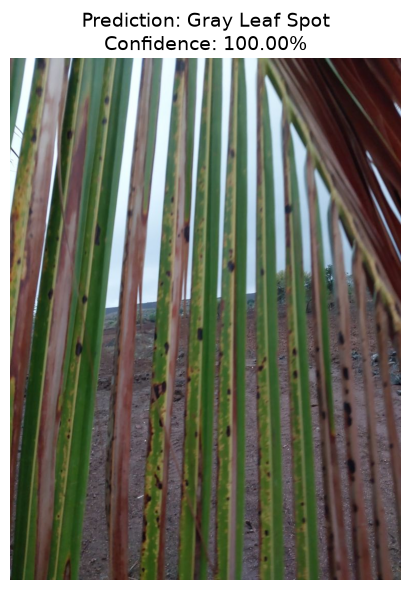

In [25]:
# ============================================================
# 9. DISPLAY IMAGE + RESULT
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    original_image
)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%",
    fontsize=14
)

plt.tight_layout()

plt.show()


In [26]:
# ============================================================
# 10. PRINT ALL CLASS PROBABILITIES
# ============================================================

print("\n" + "=" * 60)
print("PREDICTION RESULT")
print("=" * 60)

print(
    f"\nPredicted Disease : {predicted_class}"
)

print(
    f"Confidence        : "
    f"{confidence * 100:.2f}%"
)

print("\nClass probabilities:")

for class_name, probability in zip(
    CLASS_NAMES,
    predictions
):

    print(
        f"{class_name:<22} "
        f"{probability * 100:>7.2f}%"
    )

print("=" * 60)




PREDICTION RESULT

Predicted Disease : Gray Leaf Spot
Confidence        : 100.00%

Class probabilities:
Bud Root Dropping         0.00%
Bud Rot                   0.00%
Gray Leaf Spot          100.00%
Leaf Rot                  0.00%
Stem Bleeding             0.00%


In [27]:
# ============================================================
# 11. TOP-3 PREDICTIONS
# ============================================================

top_indices = np.argsort(
    predictions
)[::-1][:3]

print("\nTop 3 predictions:")

for rank, index in enumerate(
    top_indices,
    start=1
):

    print(
        f"{rank}. "
        f"{CLASS_NAMES[index]} "
        f"({predictions[index] * 100:.2f}%)"
    )


Top 3 predictions:
1. Gray Leaf Spot (100.00%)
2. Bud Rot (0.00%)
3. Stem Bleeding (0.00%)


In [28]:
# ============================================================
# 12. SIMPLE COCOCARE RESULT
# ============================================================

print("\n" + "=" * 60)

if confidence >= 0.70:

    print(
        f"COCOCARE RESULT: {predicted_class}"
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

else:

    print(
        "COCOCARE RESULT: LOW CONFIDENCE"
    )

    print(
        "Please capture another clear image "
        "of the affected coconut part."
    )

print("=" * 60)


COCOCARE RESULT: Gray Leaf Spot
Confidence: 100.00%
